# **Comment Category Prediction Challenge**

**Problem Statement**


This project aims to predict the final category assigned to user-generated comments on an online platform. It is formulated as a multiclass classification problem with four target classes (0, 1, 2, 3).

The dataset is heterogeneous, containing both unstructured and structured data, including:

* Textual content (user comments)
* Engagement signals (upvotes, downvotes)
* Emoticon indicators
* User identity attributes (race, religion, gender — with high missingness)
* Internal platform features (if_1, if_2)

**Objective**

To build a robust machine learning model that accurately predicts the category of a comment by leveraging:

* Text features (TF-IDF)
* Metadata and engagement signals
* Engineered behavioral and linguistic features

The model is evaluated primarily using Macro F1-score, as the dataset is highly imbalanced across classes.

**Project Workflow**

The project follows a structured machine learning pipeline:

1. **Data Loading & Inspection**
    * Understanding dataset structure, size, and feature distribution
2. **Exploratory Data Analysis (EDA)**
    * Identifying patterns, class imbalance, and feature importance
3. **Data Preprocessing**
    * Handling missing values
    * Cleaning and normalizing text data
    * Encoding categorical variables
    * Scaling numerical features
4. **Feature Engineering**
    * Text-based features (TF-IDF, text statistics)
    * Temporal features (date-based)
    * Engagement features (vote ratios, logs)
    * Binary and identity indicators
5. **Model Building**
    * Creating pipelines using ColumnTransformer and Pipeline
    * Training multiple models (Logistic Regression, LightGBM, etc.)
6. **Model Evaluation**
    * Using cross-validation and validation split
    * Metrics: Macro F1-score, accuracy, confusion matrix
7. **Hyperparameter Tuning**
    * Optimizing models using GridSearchCV
8. **Final Model Selection & Submission**
    * Selecting best-performing model
    * Generating predictions for test dataset

# Imports

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES AND SET CONFIGURATION
# =========================================================

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning
)

import re
import string
import numpy as np
import pandas as pd
import regex
import html

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

# **Load Dataset**

In this section, the training, test, and sample submission files are loaded and stored in separate variables.

In [2]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [3]:
# Update paths if needed
TRAIN_PATH = "/kaggle/input/comment-category-prediction-challenge/train.csv"
TEST_PATH = "/kaggle/input/comment-category-prediction-challenge/test.csv"
SUB_PATH = "/kaggle/input/comment-category-prediction-challenge/Sample.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUB_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (198000, 15)
Test shape: (102000, 14)
Sample submission shape: (102000, 2)


# **Initial Data Inspection and Dataset Overview**

This step is used to understand:

* dataset size
* feature names
* example records
* data types

# Basic Preview

In [4]:
# =========================================================
# 3. INITIAL INSPECTION
# =========================================================

display(train.head())
display(test.head())

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically fl...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,"in the future please spare me your strawman drivel, and if you can't manage an intelligent discussion, stick to posting on a public bathroom wall. That is not remotely what I believe. That's the m...",2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""corruption"". But really, either one works. olae",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the nazi flag...school children don't have the same free speech rights in, on or near public school property as adults in public... maybe you don't remember...",2


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mentality of a fifteen-year-old.
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-counsel-probe-beefs-up-bigly
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Comey, Hillary Clinton, Former President Obama, Chuck Shumer, The crowds, his hands... This President is INSANE!"
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of the WH after the Obamas moved out


# Dataset Info

In [5]:
print("Train Info:")
print(train.info())

print("\nTest Info:")
print(test.info())

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None

Test Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 t

Dataset contains structured + text + categorical + boolean + numeric features

Target variable: label (multi-class classification)

Mix of numerical, categorical, boolean and text → requires preprocessing pipeline

# Data Quality Check: Missing Values and Duplicates

Before modeling, it is important to examine missing values and duplicate rows. Missing values can affect feature engineering decisions, while duplicates can distort model evaluation if not handled properly.

# Missing Values Check

In [6]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})
print("Missing values in train:")
display(missing_df[missing> 0])

missing = test.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(test)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

print("Missing values in test:")
display(missing_df[missing> 0])

Missing values in train:


,Missing Count,Missing %
gender,145423,73.445960
race,145423,73.445960
religion,145423,73.445960
comment,1,0.000505


Missing values in test:


,Missing Count,Missing %
religion,75269,73.793137
race,75269,73.793137
gender,75269,73.793137


race, religion, gender have very high missing values (~70%+)

These columns are unreliable → dropped or converted into flags

comment has only one missing → safe 

# Duplicate Check

In [7]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


No duplicate

# **Feature Type Identification for Preprocessing Strategy**

The dataset contains multiple feature types:

* text (comment)
* datetime (created_date)
* numeric (post_id, emoticon_1, emoticon_2, emoticon_3, upvote, downvote, if_1, if_2)
* categorical (race, religion, gender)
* binary (disability)
* target (lebel)

Each type requires a different preprocessing strategy, which is handled later using a unified pipeline.

In [8]:
feature_types = {
    "text_features": ["comment"],
    "datetime_features": ["created_date"],
    "categorical_features": ["race", "religion", "gender"],
    "binary_features": ["disability"],
    "numeric_features": ["post_id", "emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2"],
    "target": ["label"]
}

for k, v in feature_types.items():
    print(f"{k}: {v}")

text_features: ['comment']
datetime_features: ['created_date']
categorical_features: ['race', 'religion', 'gender']
binary_features: ['disability']
numeric_features: ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
target: ['label']


# Exploratory Data Analysis (EDA)

EDA is performed to understand:

* label balance
* text characteristics
* numeric feature distributions
* relationships across variables
* missingness patterns

# **EDA 1: Target Class Distribution and Imbalance Check**

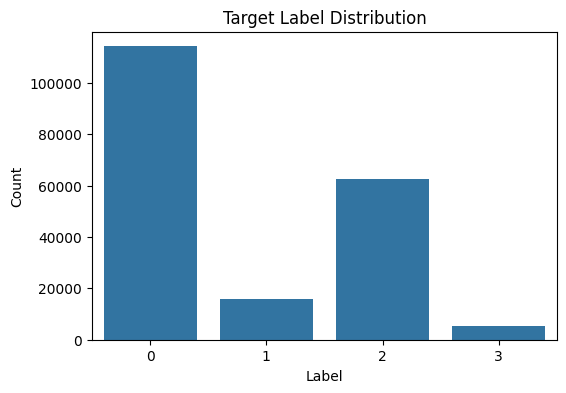

label
0    0.576631
1    0.080394
2    0.315354
3    0.027621
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="label")
plt.title("Target Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(train["label"].value_counts(normalize=True).sort_index())

The class distribution is imbalanced, with class 0 dominating and class 3 being relatively small. This imbalance makes accuracy unreliable as the main metric. Therefore, Macro F1-score is more appropriate for evaluating model performance across all classes.

# **EDA 2: Comment Length and Word Count Analysis**


The distribution of comment length is highly variable, indicating that comments differ significantly in structure and complexity. This supports the creation of text-meta features such as:

* character length
* word count


These features help capture stylistic differences between categories.

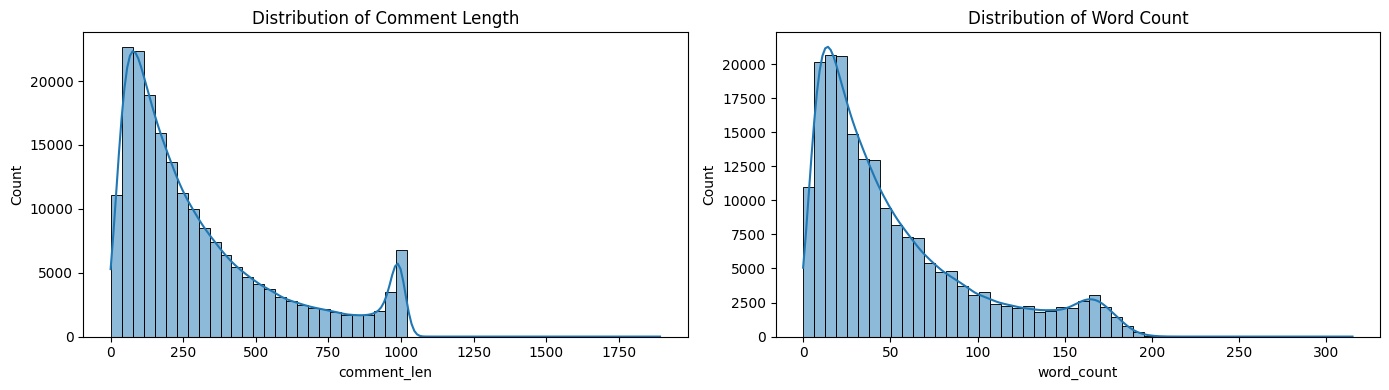

In [10]:
tmp = train.copy()
tmp["comment"] = tmp["comment"].fillna("").astype(str)
tmp["comment_len"] = tmp["comment"].str.len()
tmp["word_count"] = tmp["comment"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(tmp["comment_len"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Comment Length")

sns.histplot(tmp["word_count"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Word Count")

plt.tight_layout()
plt.show()

# EDA 3: Engagement Pattern Analysis (Upvotes vs Downvotes)

Understand user engagement

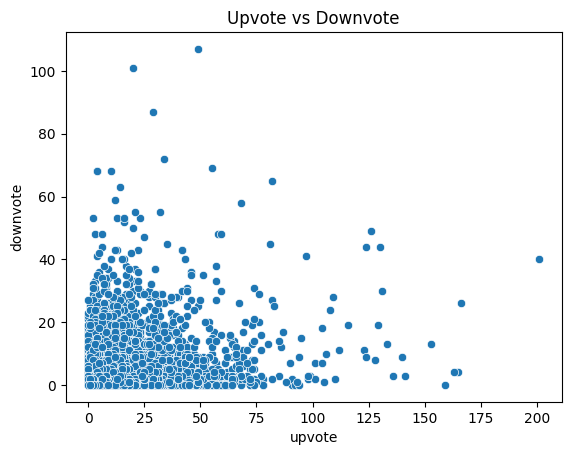

In [11]:
train["net_votes"] = train["upvote"] - train["downvote"]

sns.scatterplot(x="upvote", y="downvote", data=train)
plt.title("Upvote vs Downvote")
plt.show()

# EDA 4: Summary Statistics of Numeric Features

This helps understand spread, skewness, and possible outliers in numerical features.

In [12]:
numeric_cols = [ "emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2"]
display(train[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0


# EDA 5: Correlation Analysis of Numeric Signals

Correlation between numeric variables may help identify redundancy or useful interactions.

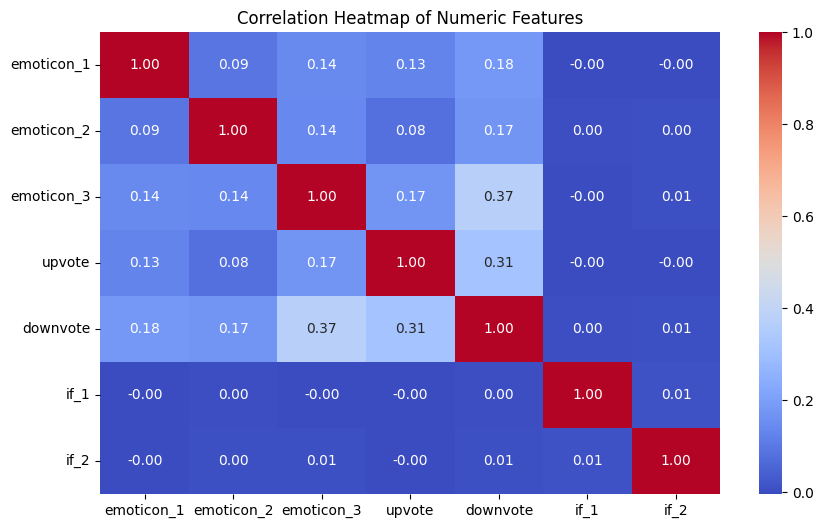

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

The correlations between numeric features are present but not excessively high. This indicates that features are not redundant and may provide complementary information. Therefore, most numeric features are retained.

# EDA 6: Feature Distribution (Numerical)

Check skewness and scaling needs

* Features are skewed → log transformation may help

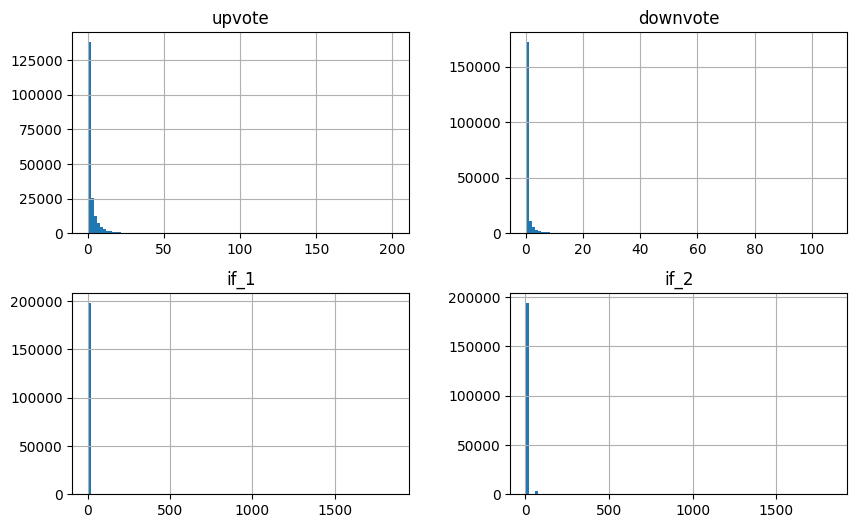

In [14]:
num_cols = ["upvote", "downvote", "if_1", "if_2"]

train[num_cols].hist(figsize=(10,6), bins=100)
plt.show()

# EDA 7: Emoticon Usage Distribution
Check usefulness of emoticons

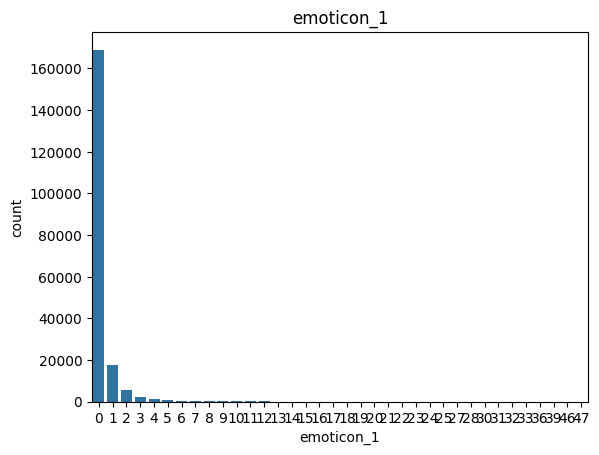

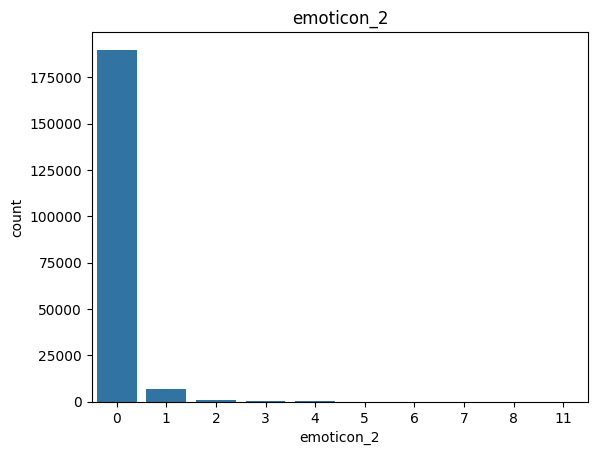

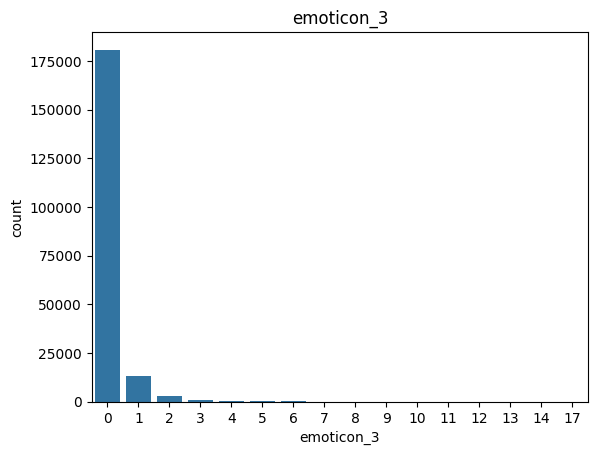

In [15]:
emo_cols = ["emoticon_1", "emoticon_2", "emoticon_3"]

for col in emo_cols:
    sns.countplot(x=col, data=train)
    plt.title(col)
    plt.show()

# EDA 8: Engagement Features by Label

This helps check whether upvotes/downvotes vary across categories.

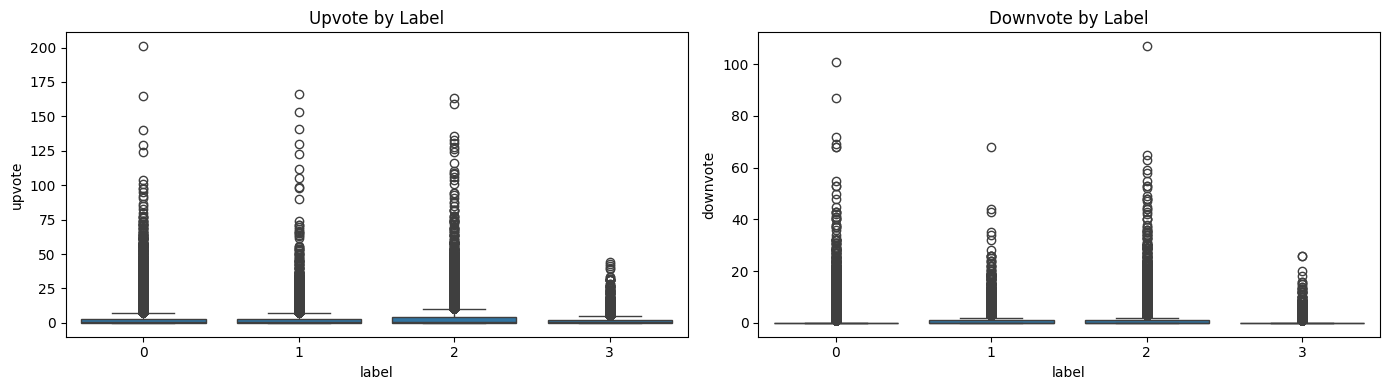

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=train, x="label", y="upvote", ax=axes[0])
axes[0].set_title("Upvote by Label")

sns.boxplot(data=train, x="label", y="downvote", ax=axes[1])
axes[1].set_title("Downvote by Label")

plt.tight_layout()
plt.show()

I analyzed outliers in upvote and downvote. These are not noise but represent real user engagement behavior (viral or controversial comments). So instead of removing them, I handled them using log transformation and feature engineering.

# EDA 9: Numeric Feature Analysis by box plot and log transformation

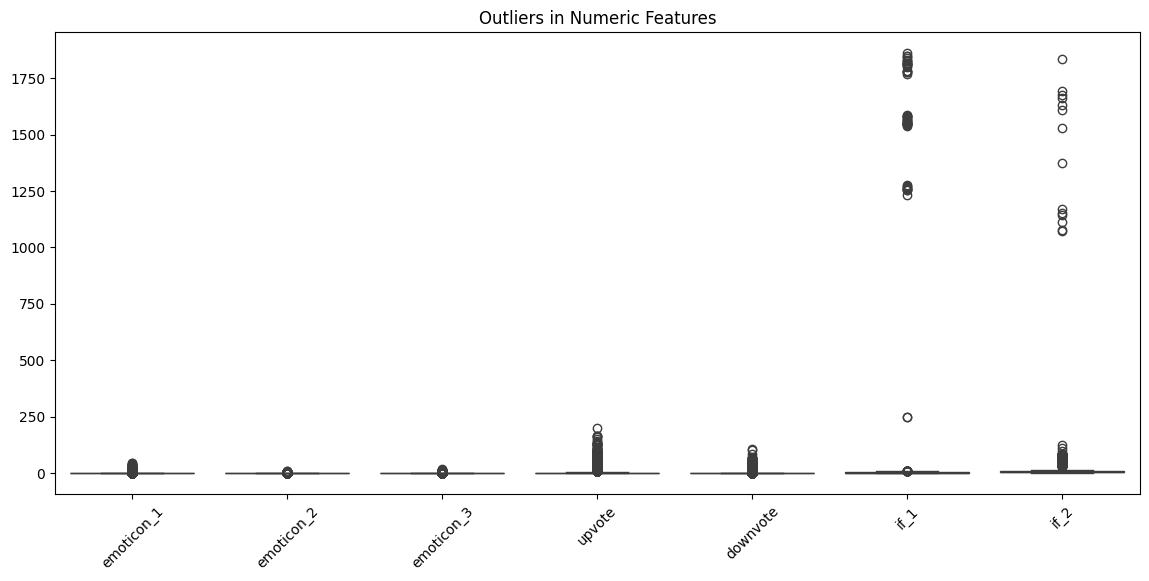

In [17]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=train[numeric_cols])

plt.title("Outliers in Numeric Features")
plt.xticks(rotation=45)
plt.show()

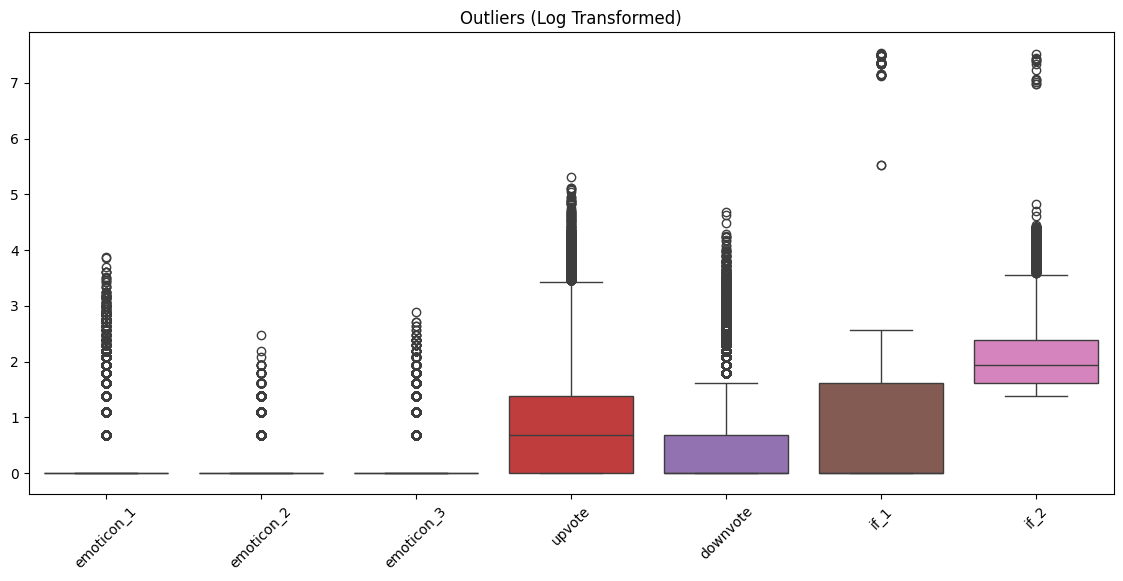

In [18]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=np.log1p(train[numeric_cols]))

plt.title("Outliers (Log Transformed)")
plt.xticks(rotation=45)
plt.show()

After applying log transformation, skewness reduced significantly. However, if_1 and if_2 still showed strong spread, indicating high predictive power. Therefore, I retained them instead of removing outliers.

# EDA 10: Temporal Patterns by Weekday and Hour


Comment patterns vary across time (weekday and hour), suggesting that behavior or moderation may depend on posting time.

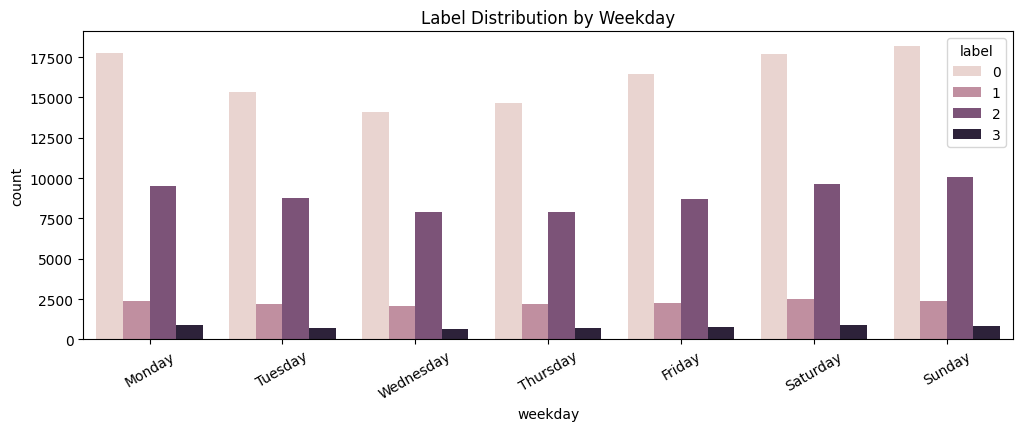

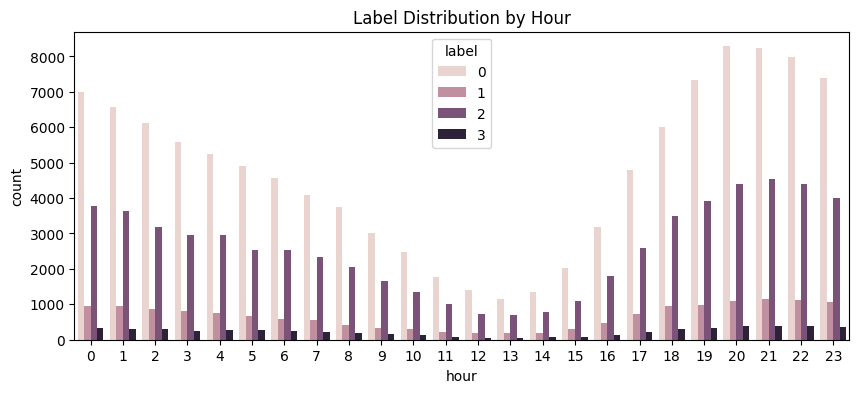

In [19]:
tmp = train.copy()
tmp["created_date"] = pd.to_datetime(tmp["created_date"], errors="coerce")
tmp["hour"] = tmp["created_date"].dt.hour
tmp["weekday"] = tmp["created_date"].dt.day_name()

plt.figure(figsize=(12, 4))
sns.countplot(
    data=tmp,
    x="weekday",
    hue="label",
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
plt.title("Label Distribution by Weekday")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=tmp, x="hour", hue="label")
plt.title("Label Distribution by Hour")
plt.show()

# EDA 11: Post ID Overlap Analysis for Context Features


The overlap between train and test post_ids is 100%, meaning all test posts appear in training. This suggests that thread-level context may be useful.

This is very important for data leakage decisions.

In [20]:
train_post_ids = set(train["post_id"].unique())
test_post_ids = set(test["post_id"].unique())

# Overlap
common_ids = train_post_ids.intersection(test_post_ids)

print("Train unique post_ids:", len(train_post_ids))
print("Test unique post_ids:", len(test_post_ids))
print("Common post_ids:", len(common_ids))

print("Overlap %:", len(common_ids) / len(test_post_ids) * 100)

Train unique post_ids: 52
Test unique post_ids: 45
Common post_ids: 45
Overlap %: 100.0


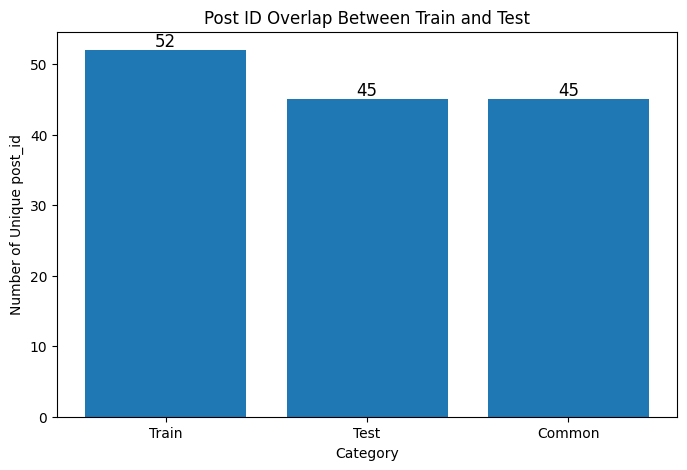

In [21]:
labels = ["Train", "Test", "Common"]
values = [len(train_post_ids), len(test_post_ids), len(common_ids)]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

for i, v in enumerate(values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=12)

plt.title("Post ID Overlap Between Train and Test")
plt.ylabel("Number of Unique post_id")
plt.xlabel("Category")

plt.show()

 overlap = 100% → safe to use post-level features

# EDA 12: Identity-Related Feature Analysis



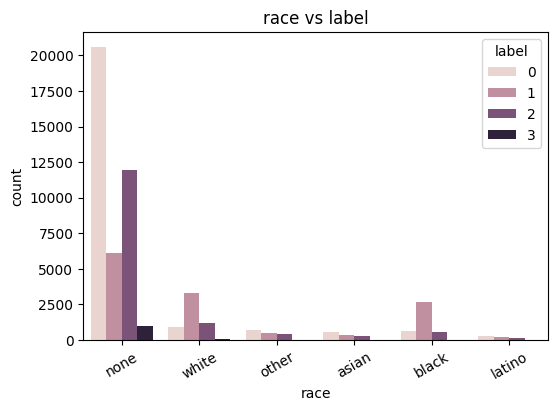

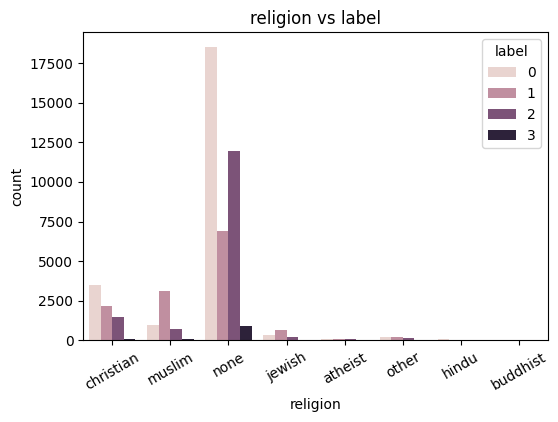

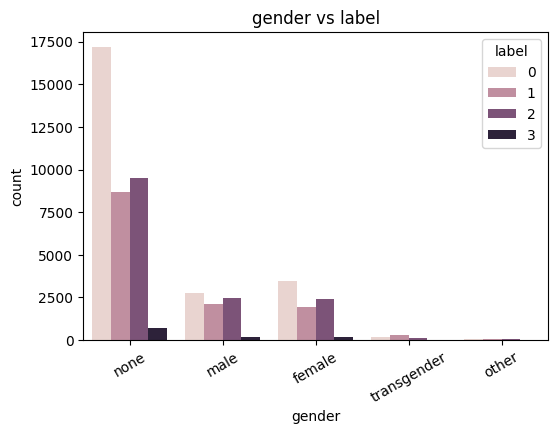

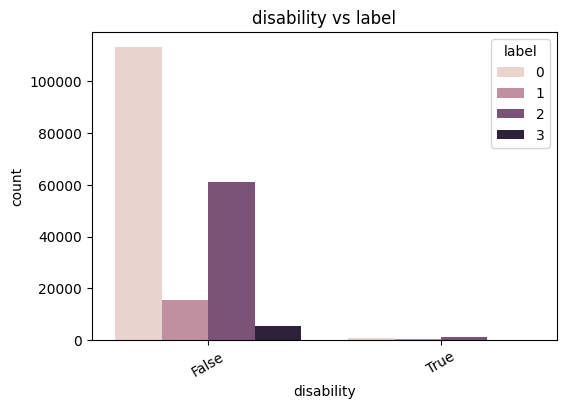

In [22]:
identity_cols = ["race", "religion", "gender", "disability"]

for col in identity_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=train, x=col, hue="label")
    plt.title(f"{col} vs label")
    plt.xticks(rotation=30)
    plt.show()

Highly sparse + missing → unreliable

Better to convert into: race_flag, religion_flag, gender_flag

# Text Cleaning and Normalization for TF-IDF Modeling
I used a text cleaning function to remove noise such as HTML tags, URLs, and special characters, normalize the text through lowercasing and token replacement, and preserve important signals like punctuation and negation. 

This helps reduce feature sparsity, improve TF-IDF representation, and ultimately leads to better model performance and generalization.

In [23]:
# -----------------------------
# MAIN CLEANING FUNCTION
# -----------------------------
def clean_text(text, use_negation_scope=False, negation_window=3):
    """
    Clean raw comment text for NLP / TF-IDF pipelines.

    Steps:
    1. Handle missing values
    2. Remove HTML, entities, invisible chars
    3. Replace URLs, emails, users, hashtags, numbers with tokens
    4. Lowercase text
    5. Normalize repeated chars / punctuation
    6. Remove unwanted characters
    7. Normalize whitespace
    8. Add negation scope
    """

    # -----------------------------
    # hashtag split
    # -----------------------------
    def process_hashtag(match):
        tag = match.group(1)

        # Split CamelCase using regex
        tag = regex.sub(r"(\p{Ll})(\p{Lu})", r"\1_\2", tag)        # aB → a_B
        tag = regex.sub(r"(\p{Lu}+)(\p{Lu}\p{Ll})", r"\1_\2", tag) # ABCd → AB_Cd

        return " HASHTAG_" + tag.lower() + " "

    if pd.isna(text):
        return ""

    text = str(text)

    # -----------------------------
    # 1. HTML + invisible cleanup
    # -----------------------------
    text = html.unescape(text)                                   # HTML entities decode
    text = regex.sub(r"<[^>]+>", " ", text)                     # HTML tags
    text = regex.sub(r"[\u200B-\u200D\uFEFF\u2060]", "", text)  # zero-width chars

    # -----------------------------
    # 2. Replace structured patterns 
    # -----------------------------
    text = regex.sub(r"\b(?:https?://|www\.)\S+\b", " URL ", text)   # URLs
    text = regex.sub(r"\b[\p{L}\p{N}._%+-]+@[\p{L}\p{N}.-]+\.[\p{L}]{2,}\b", " EMAIL ", text)  # Emails
    text = regex.sub(r"(?<!\S)@[\p{L}\p{N}_.]+", " USER ", text)     # Mentions

    # Hashtag → split + convert
    text = regex.sub(r"(?<!\S)#([\p{L}\p{N}_]+)", process_hashtag, text)

    text = regex.sub(r"\b\d+(?:[\.,]\d+)?\b", " NUM ", text)         # Numbers

    # -----------------------------
    # 3. Lowercase normalization
    # -----------------------------
    text = text.lower()

    # -----------------------------
    # 4. Normalize text patterns
    # -----------------------------
    # Example: "sooooo good" -> "soo good"
    text = regex.sub(r"(.)\1{2,}", r"\1\1", text)       # repeated chars

    # Example: "!!!!!" -> "!!"
    text = regex.sub(r"([!?.,])\1+", r"\1\1", text)     # repeated punctuation

    # -----------------------------
    # 5. Remove unwanted characters
    # -----------------------------
    text = regex.sub(r"[^\p{L}\p{N}\s!\?\.,\-\'\"_#]+", " ", text)

    # -----------------------------
    # 6. Normalize whitespace
    # -----------------------------
    text = regex.sub(r"\s+", " ", text).strip()

    # -----------------------------
    # 7. NEGATION HANDLING 
    # -----------------------------
    # add negation scope features

    """
    Mark the next few tokens after a negation word.

    Example:
    "not good at all" ->
    "not NOT_good NOT_at NOT_all"

    This can help linear models like Logistic Regression
    capture polarity better.
    """
    if use_negation_scope and text:
        tokens = text.split()
        new_tokens = []

        neg_pattern = regex.compile(
            r"^(?:not|no|never|none|nothing|nowhere|neither|nor|"
            r"cannot|can't|won't|don't|doesn't|didn't|isn't|aren't|"
            r"wasn't|weren't|haven't|hasn't|hadn't|shouldn't|"
            r"wouldn't|couldn't|mustn't|.*n't)$"
        )

        scope_left = 0

        for token in tokens:
            if neg_pattern.fullmatch(token):
                scope_left = negation_window
                continue

            if scope_left > 0:
                new_tokens.append("NOT_" + token)
                scope_left -= 1
            else:
                new_tokens.append(token)

        text = " ".join(new_tokens)

    return text

# Feature engineering

Feature engineering is the process of creating new meaningful features or transforming existing ones to improve the performance of machine learning models.

Models cannot directly understand raw data effectively, especially text and timestamps.

Feature engineering helps uncover patterns that are not directly visible.

Helps remove irrelevant information and focus on important patterns.

In [24]:
def preprocess_dataframe(df, min_date=None):
    df = df.copy()

    # ---------- text ----------
    df["comment_clean"] = df["comment"].apply(lambda x: clean_text(x, use_negation_scope=True))

    # ---------- categorical ----------
    for col in ["race", "religion", "gender"]:
        df[col] = df[col].fillna("missing").astype(str)

    # ---------- binary ----------
    df["disability"] = df["disability"].fillna(False).astype(int)

    # ---------- post_id ----------
    df["post_id"] = df["post_id"].fillna(df["post_id"].mode()[0])

    # ---------- numeric ----------
    num_cols = ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
                "upvote", "downvote", "if_1", "if_2"]
    
    df[num_cols] = df[num_cols].apply(lambda col: col.fillna(col.median()))

    # ---------- datetime ----------
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
    df["year"] = df["created_date"].dt.year.fillna(0).astype(int)
    df["month"] = df["created_date"].dt.month.fillna(0).astype(int)
    df["day"] = df["created_date"].dt.day.fillna(0).astype(int)
    df["hour"] = df["created_date"].dt.hour.fillna(0).astype(int)
    df["minute"] = df["created_date"].dt.minute.fillna(0).astype(int)
    df["weekday"] = df["created_date"].dt.weekday.fillna(0).astype(int)
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

    # -------------------------
    # DAYS SINCE START 
    # -------------------------
    if min_date is None or pd.isna(min_date):
        df["days_since_start"] = 0
    else:
        df["days_since_start"] = (
            (df["created_date"] - min_date)
            .dt.days
            .fillna(0)
            .clip(lower=0)
        )

    # ---------- text meta features ----------

    # ---------- text meta features ----------
    
    
    s = df["comment"].astype(str)
    
    # basic
    df["txt_len"] = s.str.len()
    df["txt_words"] = s.str.split().apply(len)
    df["txt_unique_words"] = s.apply(lambda x: len(set(x.split())))
    df["txt_word_density"] = df["txt_words"] / (df["txt_len"] + 1)
    
    # punctuation and symbols
    df["txt_exclam"] = s.str.count("!")
    df["txt_question"] = s.str.count(r"\?")
    df["txt_punct"] = s.apply(lambda x: sum(1 for ch in x if ch in string.punctuation))
    df["txt_punct_ratio"] = df["txt_punct"] / (df["txt_len"] + 1)
    
    # special patterns
    df["txt_digits"] = s.str.count(r"\d")
    df["txt_has_number"] = (df["txt_digits"] > 0).astype(int)
    df["txt_has_url"] = s.str.contains("http|www").astype(int)
    df["txt_has_email"] = s.str.contains("@").astype(int)
    
    # uppercase features
    upper = s.str.count(r"[A-Z]")
    alpha = s.str.count(r"[A-Za-z]").replace(0, np.nan)
    
    df["txt_upper_ratio"] = (upper / alpha).fillna(0)
    df["txt_upper_count"] = upper
    
    # word based features
    df["txt_long_words"] = s.apply(lambda x: sum(1 for w in x.split() if len(w) > 6))
    df["txt_short_words"] = s.apply(lambda x: sum(1 for w in x.split() if len(w) <= 3))
    
    # repetition patterns
    df["txt_repeated_chars"] = s.str.count(r"(.)\1{2,}")  # e.g., "soooo", "!!!"
    df["txt_repeated_words"] = s.apply(lambda x: sum(1 for i in range(len(x.split())-1) if x.split()[i] == x.split()[i+1]))

    
    # hashtag/topic intensity
    df["hashtag_count"] = s.str.count(r"#")
    
    # strong uppercase emphasis
    df["has_caps_word"] = s.str.contains(r"\b[A-Z]{3,}\b", regex=True).astype(int)
    
    # emoji / symbol presence
    df["has_emoji"] = s.str.contains(r"[^\w\s,]", regex=True).astype(int)
    
    # stronger keyword lists  # sentiment-like signals 
    df["txt_pos_signal"] = s.str.count(r"\b(good|great|nice|love|awesome|best|amazing)\b")
    df["txt_neg_signal"] = s.str.count(r"\b(bad|worst|hate|terrible|awful|disgusting)\b")
    
    # question / statement behavior
    df["is_question"] = (df["txt_question"] > 0).astype(int)
    df["is_exclamation"] = (df["txt_exclam"] > 0).astype(int)
    
    # emoji / emotive signals 
    df["txt_emphasis"] = df["txt_exclam"] + df["txt_question"]
    df["txt_intensity"] = df["txt_upper_ratio"] + df["txt_emphasis"]
    
    # lexical diversity
    df["lexical_diversity"] = df["txt_unique_words"] / (df["txt_words"] + 1)
    
    # readability proxy
    df["chars_per_word"] = df["txt_len"] / (df["txt_words"] + 1)
    
    # binary flags
    df["is_short_comment"] = (df["txt_words"] < 5).astype(int)
    df["is_long_comment"] = (df["txt_words"] > 20).astype(int)


    # ---------- engagement features ----------
    df["total_reactions"] = df["upvote"] + df["downvote"]
    df["net_votes"] = df["upvote"] - df["downvote"]
    df["upvote_ratio"] = df["upvote"] / (df["total_reactions"] + 1)
    df["downvote_ratio"] = df["downvote"] / (df["total_reactions"] + 1)
    df["controversy"] = np.minimum(df["upvote"], df["downvote"])

    # ---------- log transforms ----------
    df["upvote_log"] = np.log1p(df["upvote"])
    df["downvote_log"] = np.log1p(df["downvote"])
    df["if1_log"] = np.log1p(df["if_1"])
    df["if2_log"] = np.log1p(df["if_2"])

    # ---------- identity aggregate ----------
    df["race_flag"] = (df["race"] != "missing").astype(int)
    df["religion_flag"] = (df["religion"] != "missing").astype(int)
    df["gender_flag"] = (df["gender"] != "missing").astype(int)
    df["identity_count"] = df[["race_flag", "religion_flag", "gender_flag"]].sum(axis=1) + df["disability"]

    # ---------- emoticon aggregate ----------
    df["has_any_emoticon"] = (
        (df["emoticon_1"] > 0) |
        (df["emoticon_2"] > 0) |
        (df["emoticon_3"] > 0)
    ).astype(int)

    df["total_emoticon_score"] = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]
    
    # ---------- interaction features ----------
    df["identity_x_upvote"] = df["identity_count"] * df["upvote"]
    df["identity_x_downvote"] = df["identity_count"] * df["downvote"]


    # drop 
    df = df.drop(columns=["created_date"])

    return df

# Apply Preprocessing

Preprocessing is important because raw data is not directly suitable for machine learning models. 

It ensures data is clean, properly formatted, and consistent by handling missing values, encoding categorical variables, scaling numerical features, and transforming text data. 

This leads to better model performance and reliable predictions.



In [25]:
train["created_date"] = pd.to_datetime(train["created_date"], errors="coerce")
test["created_date"] = pd.to_datetime(test["created_date"], errors="coerce")

train_min_date = train["created_date"].min()
train_processed = preprocess_dataframe(train, min_date=train_min_date)
test_processed = preprocess_dataframe(test, min_date=train_min_date)

print("Processed train shape:", train_processed.shape)
print("Processed test shape:", test_processed.shape)

display(train_processed.head())

Processed train shape: (198000, 71)
Processed test shape: (102000, 70)


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,net_votes,comment_clean,year,month,day,hour,minute,weekday,is_weekend,days_since_start,txt_len,txt_words,txt_unique_words,txt_word_density,txt_exclam,txt_question,txt_punct,txt_punct_ratio,txt_digits,txt_has_number,txt_has_url,txt_has_email,txt_upper_ratio,txt_upper_count,txt_long_words,txt_short_words,txt_repeated_chars,txt_repeated_words,hashtag_count,has_caps_word,has_emoji,txt_pos_signal,txt_neg_signal,is_question,is_exclamation,txt_emphasis,txt_intensity,lexical_diversity,chars_per_word,is_short_comment,is_long_comment,total_reactions,upvote_ratio,downvote_ratio,controversy,upvote_log,downvote_log,if1_log,if2_log,race_flag,religion_flag,gender_flag,identity_count,has_any_emoticon,total_emoticon_score,identity_x_upvote,identity_x_downvote
0,73,0,0,0,0,1,0,10,missing,missing,missing,0,She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.,2,-1,she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.,2024,1,18,8,43,3,0,628,118,20,19,0.168067,0,0,1,0.008403,0,0,0,0,0.020408,2,5,8,0,0,0,0,1,0,0,0,0,0,0.020408,0.904762,5.619048,0,0,1,0.000000,0.5,0,0.000000,0.693147,0.0,2.397895,0,0,0,0,0,0,0,0
1,39,0,0,0,6,0,0,4,missing,missing,missing,0,"Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically fl...",0,6,"under alaska law, a non-tribal member is NOT_bound NOT_to NOT_tribal court.. living in a particular community does NOT_change NOT_your NOT_rights under state and federal law. in this case, connor ...",2024,3,24,21,43,6,1,695,644,110,74,0.170543,0,0,14,0.021705,0,0,0,0,0.017308,9,25,39,0,0,0,0,1,1,0,0,0,0,0.017308,0.666667,5.801802,0,1,6,0.857143,0.0,0,1.945910,0.000000,0.0,1.609438,0,0,0,0,0,0,0,0
2,31,0,1,1,0,0,0,10,missing,missing,missing,0,"in the future please spare me your strawman drivel, and if you can't manage an intelligent discussion, stick to posting on a public bathroom wall. That is not remotely what I believe. That's the m...",2,0,"in the future please spare me your strawman drivel, and if you NOT_manage NOT_an NOT_intelligent discussion, stick to posting on a public bathroom wall. that is NOT_remotely NOT_what NOT_i believe...",2024,4,24,20,32,2,0,726,751,133,97,0.176862,0,0,18,0.023936,1,1,0,0,0.021667,13,30,53,0,0,0,1,1,0,0,0,0,0,0.021667,0.723881,5.604478,0,1,0,0.000000,0.0,0,0.000000,0.000000,0.0,2.397895,0,0,0,0,1,2,0,0
3,39,0,0,0,5,0,0,10,missing,missing,missing,0,"PS: That should have been ""rot"" instead of ""corruption"". But really, either one works. olae",2,5,"ps that should have been ""rot"" instead of ""corruption"". but really, either one works. olae",2023,5,28,22,0,6,1,394,91,15,15,0.163043,0,0,8,0.086957,0,0,0,0,0.057971,4,3,4,0,0,0,0,1,0,0,0,0,0,0.057971,0.937500,5.687500,0,0,5,0.833333,0.0,0,1.791759,0.000000,0.0,2.397895,0,0,0,0,0,0,0,0
4,39,0,0,0,0,0,0,10,missing,missing,missing,0,"Today, the confederate flag...tomorrow, the nazi flag...school children don't have the same free speech rights in, on or near public school property as adults in public... maybe you don't remember...",2,0,"today, the confederate flag..tomorrow, the nazi flag..school children NOT_have NOT_the NOT_same free speech rights in, on or near public school property as adults in public.. maybe you NOT_remembe...",2023,9,9,23,12,5,1,498,254,40,37,0.156863,0,0,20,0.078431,0,0,0,0,0.015385,3,8,14,4,0,0,0,1,0,0,0,0,0,0.015385,0.902439,6.195122,0,1,0,0.000000,0.0,0,0.000000,0.000000,0.0,2.397895,0,0,0,0,0,0,0,0


# Label Encoding

I encoded the target labels into integers because the classifiers require numeric target values. I also kept the label encoder so that predictions can be converted back to original class names.

In [26]:
label_encoder = LabelEncoder()
train_processed["label_encoded"] = label_encoder.fit_transform(train_processed["label"])

print("Classes:", list(label_encoder.classes_))

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


# Prepare Features and Target
I removed the target columns from the training features and kept a separate processed test feature set for final prediction.

In [27]:
X = train_processed.drop(columns=["label", "label_encoded"])
y = train_processed["label_encoded"]

X_test_final = test_processed.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (198000, 70)
y shape: (198000,)


# **Build the Unified Preprocessing Pipeline**

A pipeline is used to combine preprocessing and model training into a single workflow. 

It ensures consistent transformations, prevents data leakage, simplifies code, and makes hyperparameter tuning easier. 

This leads to more reliable and reproducible model performance.

The dataset contains mixed feature types, so I used different preprocessing for each. Text was vectorized using word-level and character-level TF-IDF. Numeric columns were imputed and scaled. Categorical columns were imputed and one-hot encoded. Binary columns were passed through directly. A single pipeline keeps the workflow consistent and avoids preprocessing mismatch between training and test data.

Different feature types require different preprocessing:

* DEFINE FEATURE GROUPS
* **text** → hybrid TF-IDF
* **categorical** → imputation + one-hot encoding
* **numeric**→ imputation + scaling
* **binary** → passthrough

# Define Column Groups

I grouped columns by data type and modeling role. This is necessary because text, categorical, numeric, and binary variables need different transformations before they can be used together in a single model.

In [28]:
text_col = "comment_clean"

categorical_cols = [ "gender"]

binary_cols = [
    "disability", "is_weekend",
    "race_flag", "religion_flag", "gender_flag",
    "has_any_emoticon",
    "txt_has_number", "txt_has_url", "txt_has_email",
    "is_question", "is_exclamation",
    "is_short_comment", "is_long_comment"
]

numeric_cols_final = [
    "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2",
    "year", "month", "day", "hour", "minute", "weekday", "days_since_start",
    "txt_len", "txt_words", "txt_exclam", "txt_question", "txt_digits",
    "txt_punct", "txt_upper_ratio", 
    "txt_unique_words", "txt_word_density", "txt_punct_ratio",
    "txt_upper_count", "txt_long_words", "txt_short_words",
    "txt_repeated_chars", "txt_repeated_words",
    "has_caps_word", "hashtag_count", "has_emoji",
    "txt_pos_signal", "txt_neg_signal",
    "txt_emphasis", "txt_intensity",
    "lexical_diversity", "chars_per_word",
    "total_reactions", "net_votes", "upvote_ratio", "downvote_ratio", "controversy",
    "upvote_log", "downvote_log", "if1_log", "if2_log",
    "identity_count", "total_emoticon_score",
    "identity_x_upvote", "identity_x_downvote"
]

# BUILD PREPROCESSOR

Word-level TF-IDF captures semantic meaning, while character-level TF-IDF captures subword patterns and noise robustness. Combining both improves model performance.

Character n-grams help capture morphological patterns and handle out-of-vocabulary words, which complements word-level features.

I used both word-level and character-level TF-IDF vectorizers. Word TF-IDF captures semantic meaning using unigrams and bigrams, while character TF-IDF captures subword patterns and handles noisy text. Together, they improve robustness and model performance.

In [29]:
# -------------------------
# 1) TEXT VECTORIZERS
# -------------------------

# Word-level TF-IDF
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    max_features=50000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    strip_accents="unicode",
    norm="l2",
    stop_words=None  
)

# Character-level TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=30000,
    min_df=3,
    strip_accents="unicode",
    norm="l2"
)

# -------------------------
# 2) TEXT PIPELINE
# -------------------------
text_pipeline = Pipeline([
    ("selector", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
    ("tfidf_union", FeatureUnion([
        ("word_tfidf", word_tfidf),
        ("char_tfidf", char_tfidf)
    ]))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

num_pipeline_standard = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_pipeline_minmax = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])





def build_pipeline(model_name, model):

    # choose numeric pipeline
    if "NB" in model_name:
        num_pipeline = num_pipeline_minmax
    else:
        num_pipeline = num_pipeline_standard

    # full preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "text",
                text_pipeline,   # hybrid TF-IDF
                [text_col]
            ),
            (
                "cat",
                cat_pipeline,
                categorical_cols
            ),
            (
                "num",
                num_pipeline,
                numeric_cols_final
            ),
            (
                "bin",
                "passthrough",
                binary_cols
            )
        ],
        remainder="drop"
    )

    # final pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipe

# Train–Validation Split

Train–Validation split is important to evaluate how well the model generalizes to unseen data. 

It helps in detecting overfitting, tuning hyperparameters, and selecting the best model. 

Without it, we risk building a model that performs well only on training data but fails in real-world scenarios.

I used a stratified train-validation split so that the class distribution remains similar in both sets. 

This gives a more reliable estimate of model performance on unseen data.

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(158400, 70) (39600, 70) (158400,) (39600,)


# Baseline Model Selection and Justification

Different models are selected to capture different aspects:


 * Logistic Regression → Strong sparse-text baseline                            
 * Ridge               → Linear regularized classifier                          
 * SGD                 → Efficient linear learner for high-dimensional text     
 * MultinomialNB       → Standard text baseline                                 
 * ComplementNB        → Better than MultinomialNB for imbalanced text          
 * BernoulliNB         → Binary-event text baseline                             
 * LightGBM            → Captures nonlinear interactions in structured features 


In [31]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, tol=2e-3, random_state=RANDOM_STATE),
    "Ridge": RidgeClassifier(random_state=RANDOM_STATE),
    "SGD": SGDClassifier(random_state=RANDOM_STATE),
    "MultinomialNB": MultinomialNB(),  
    "ComplementNB": ComplementNB(),    
    "BernoulliNB": BernoulliNB(),      
    "LGBM": LGBMClassifier(verbose=0, random_state=RANDOM_STATE),
}

# Baseline Model Performance Comparison




In [32]:

holdout_results = []

fitted_models = {}

for model_name, model in models.items():
    pipe = build_pipeline(model_name, model)

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="macro")

    holdout_results.append({
        "Model": model_name,
        "Holdout Accuracy": acc,
        "Holdout F1 Macro": f1
    })

    fitted_models[model_name] = pipe

holdout_results_df = pd.DataFrame(holdout_results).sort_values("Holdout F1 Macro", ascending=False)
display(holdout_results_df)


,Model,Holdout Accuracy,Holdout F1 Macro
6,LGBM,0.915909,0.815068
0,LogisticRegression,0.900808,0.777054
1,Ridge,0.889520,0.759490
2,SGD,0.897045,0.739415
4,ComplementNB,0.684621,0.577505
3,MultinomialNB,0.725177,0.543492
5,BernoulliNB,0.381414,0.377563


LightGBM performs best among baseline models, followed closely by Logistic Regression. This indicates that both:

* sparse TF-IDF text features
* nonlinear interactions in metadata

are important for this task.

Ridge and SGD perform reasonably but lag behind the top two models, indicating that stronger calibration of regularization or nonlinear modeling is beneficial.

Naive Bayes variants perform much worse, which suggests that the dataset contains more complex relationships than simple word-frequency assumptions can capture, especially after mixing sparse text and engineered metadata.

BernoulliNB performs the worst because the binary-event assumption is not well aligned with this feature space.

# Plot Model Comparison

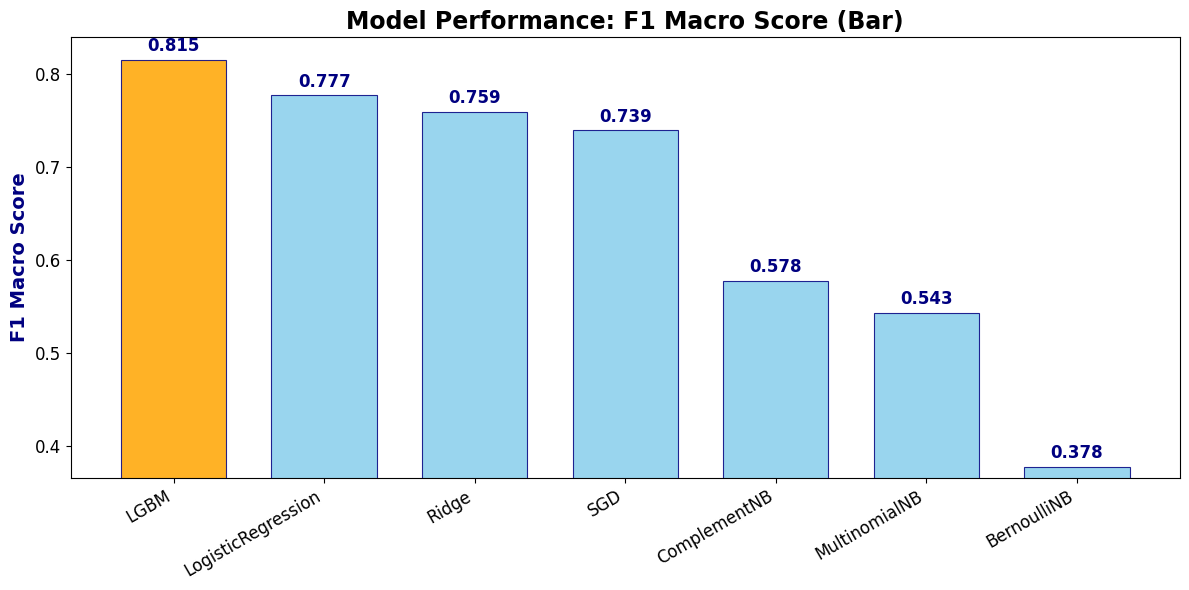

In [33]:
# Assuming df is your DataFrame with 'model_name' and 'f1_score' columns
df = holdout_results_df.sort_values(by="Holdout F1 Macro", ascending=False).reset_index(drop=True)

models = df['Model']
f1_scores = df['Holdout F1 Macro']
x = np.arange(len(models))

# Detect highest F1 score index
max_idx = f1_scores.idxmax()
colors = ['orange' if i == max_idx else 'skyblue' for i in df.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    x, f1_scores,
    color=colors,
    width=0.7,
    alpha=0.85,
    edgecolor='navy',     # Border color
    linewidth=.8           # Border thickness
)

# Y-axis label
ax.set_ylabel('F1 Macro Score', fontsize=14, fontweight='bold', color='navy')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(min(f1_scores)*0.97, max(f1_scores)*1.03)

# Annotate each bar
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
            f'{yval:.3f}',
            ha='center', va='bottom',
            fontsize=12, color='navy', fontweight='bold')

plt.title('Model Performance: F1 Macro Score (Bar)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()


# Class-wise Performance of the Best Baseline Model

A classification report is used to evaluate model performance in detail by providing precision, recall, and F1-score for each class. 

It is especially useful in multi-class or imbalanced datasets where accuracy alone is not sufficient. 

It helps ensure that the model performs well across all classes.

In [34]:
best_baseline_model_name = holdout_results_df.iloc[0]["Model"]
best_baseline_model = fitted_models[best_baseline_model_name]

val_preds = best_baseline_model.predict(X_val)

print("Best baseline model:", best_baseline_model_name)
print(classification_report(y_val, val_preds, target_names=[str(c) for c in label_encoder.classes_]))

Best baseline model: LGBM
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.79      0.78      0.78      3183
           2       0.85      0.92      0.89     12488
           3       0.76      0.53      0.63      1094

    accuracy                           0.92     39600
   macro avg       0.84      0.80      0.82     39600
weighted avg       0.92      0.92      0.92     39600



The baseline LightGBM model performs very well on classes 0 and 2, indicating that these classes are easier to separate. Class 1 is moderately difficult, while class 3 is the hardest class with the lowest recall and F1-score. This suggests both class imbalance and overlap in feature space for the harder classes.

The gap between weighted average and macro average indicates that the model performs better on majority classes than minority classes, so macro F1 is a more appropriate comparison metric than accuracy alone.

# Confusion Matrix Analysis of the Best Baseline Model

A confusion matrix is used to analyze model performance in detail by showing correct and incorrect predictions for each class. 

It helps identify which classes are being misclassified and provides insights into model errors, which is essential for improving the model.

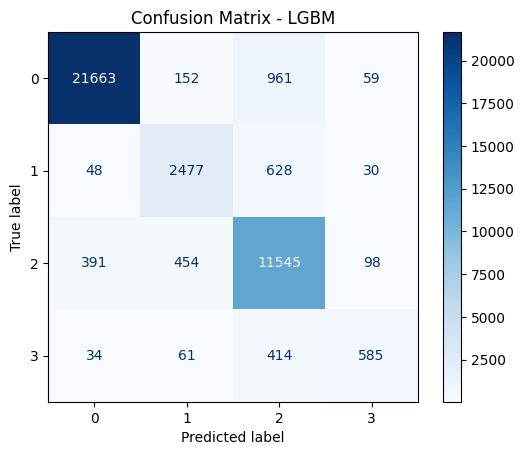

In [35]:
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_baseline_model_name}")
plt.show()

The confusion matrix shows:

* class 3 is frequently confused with class 2
* class 1 also overlaps with class 2
* class 0 is easiest to predict

# Hyperparameter Tuning: Logistic Regression

Hyperparameter tuning is important because it helps optimize model performance by finding the best parameter values. 

It improves generalization, prevents overfitting and underfitting, and ensures better performance on unseen data.

I focused on tuning Logistic Regression because it is highly effective for sparse TF-IDF features and provides strong baseline performance. 

It has fewer hyperparameters and is faster to tune compared to LightGBM. 

Given computational constraints, tuning Logistic Regression offered a better trade-off between performance improvement and training time.

In [36]:
# Model
log_model = LogisticRegression(max_iter=6000, random_state=RANDOM_STATE)

# Pipeline
log_pipe = build_pipeline("LogisticRegression", log_model)

# Grid params 
log_params = {
    "model__C": [1.7017173314669507, 2.1833289550971693, 2.2157794479684614, 2.35018883368057],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__class_weight": ["balanced", {0: 1.0, 1: 2.0, 2: 1.0, 3: 3.2}]
}

# Grid Search
log_search = GridSearchCV(
    estimator=log_pipe,
    param_grid=log_params,
    scoring="f1_macro",
    cv=3,
    verbose=0,
    n_jobs=-1
)

# Fit
log_search.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('text',
                                                                         Pipeline(steps=[('selector',
                                                                                          FunctionTransformer(func=<function <lambda> at 0x7f4ab805bce0>)),
                                                                                         ('tfidf_union',
                                                                                          FeatureUnion(transformer_list=[('word_tfidf',
                                                                                                                          TfidfVectorizer(max_df=0.9,
                                                                                                                                          max_features=50000,
                                                                                                                                          min_df=3,
                                                                                                                                          ngram_range=(1,
                                                                                                                                                       2),
                                                                                                                                          strip_accents='unicode',
                                                                                                                                          sub...
                                                                          'is_exclamation',
                                                                          'is_short_comment',
                                                                          'is_long_comment'])])),
                                       ('model',
                                        LogisticRegression(max_iter=6000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [1.7017173314669507, 2.1833289550971693,
                                      2.2157794479684614, 2.35018883368057],
                         'model__class_weight': ['balanced',
                                                 {0: 1.0, 1: 2.0, 2: 1.0,
                                                  3: 3.2}],
                         'model__penalty': ['l2'], 'model__solver': ['lbfgs']},
             scoring='f1_macro')

# Hyperparameter Tuning: LGBM

In [37]:
lgbm_model = LGBMClassifier(
    objective="multiclass",
    random_state=RANDOM_STATE,
    verbose=0,
    n_jobs=-1
)

lgbm_pipe = build_pipeline("LGBM", lgbm_model)

lgbm_param_grid = {
    "model__class_weight": [ "balanced", {0:1, 1:1.8, 2:1.0, 3:3.2}]
}

lgbm_search = GridSearchCV(
    estimator=lgbm_pipe,
    param_grid=lgbm_param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=0,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('text',
                                                                         Pipeline(steps=[('selector',
                                                                                          FunctionTransformer(func=<function <lambda> at 0x7f4ab805bce0>)),
                                                                                         ('tfidf_union',
                                                                                          FeatureUnion(transformer_list=[('word_tfidf',
                                                                                                                          TfidfVectorizer(max_df=0.9,
                                                                                                                                          max_features=50000,
                                                                                                                                          min_df=3,
                                                                                                                                          ngram_range=(1,
                                                                                                                                                       2),
                                                                                                                                          strip_accents='unicode',
                                                                                                                                          sub...
                                                                          'religion_flag',
                                                                          'gender_flag',
                                                                          'has_any_emoticon',
                                                                          'txt_has_number',
                                                                          'txt_has_url',
                                                                          'txt_has_email',
                                                                          'is_question',
                                                                          'is_exclamation',
                                                                          'is_short_comment',
                                                                          'is_long_comment'])])),
                                       ('model',
                                        LGBMClassifier(n_jobs=-1,
                                                       objective='multiclass',
                                                       random_state=42,
                                                       verbose=0))]),
             n_jobs=-1,
             param_grid={'model__class_weight': ['balanced',
                                                 {0: 1, 1: 1.8, 2: 1.0,
                                                  3: 3.2}]},
             scoring='f1_macro')

#  Validation Performance of the Tuned Model

Evaluating the tuned model is important to verify whether hyperparameter tuning has actually improved performance. 

It helps ensure better generalization, detect overfitting, and select the best model based on validation metrics.

In [38]:
tuned_models = {
    "Tuned LogisticRegression": log_search.best_estimator_,
    "Tuned LGBM": lgbm_search.best_estimator_,
}

for model_name, model in tuned_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    holdout_results.append({
        "Model": model_name,
        "Holdout Accuracy": accuracy_score(y_val, preds),
        "Holdout F1 Macro": f1_score(y_val, preds, average="macro")
    })

    fitted_models[model_name] = model

tuned_results_df = pd.DataFrame(holdout_results).sort_values("Holdout F1 Macro", ascending=False)
display(tuned_results_df)

,Model,Holdout Accuracy,Holdout F1 Macro
8,Tuned LGBM,0.915581,0.828099
7,Tuned LogisticRegression,0.910934,0.818640
6,LGBM,0.915909,0.815068
0,LogisticRegression,0.900808,0.777054
1,Ridge,0.889520,0.759490
2,SGD,0.897045,0.739415
4,ComplementNB,0.684621,0.577505
3,MultinomialNB,0.725177,0.543492
5,BernoulliNB,0.381414,0.377563


# Compare Tuned Models with Baseline model

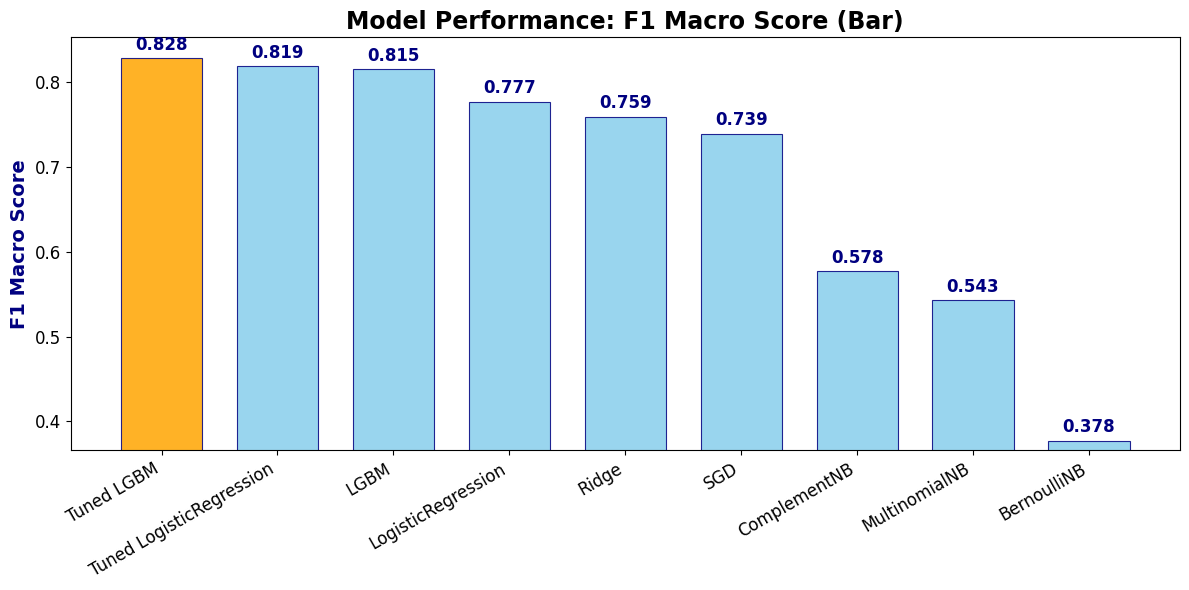

In [39]:
# Assuming df is your DataFrame with 'model_name' and 'f1_score' columns
df = tuned_results_df.sort_values(by="Holdout F1 Macro", ascending=False).reset_index(drop=True)

models = df['Model']
f1_scores = df['Holdout F1 Macro']
x = np.arange(len(models))

# Detect highest F1 score index
max_idx = f1_scores.idxmax()
colors = ['orange' if i == max_idx else 'skyblue' for i in df.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    x, f1_scores,
    color=colors,
    width=0.7,
    alpha=0.85,
    edgecolor='navy',     # Border color
    linewidth=.8           # Border thickness
)

# Y-axis label
ax.set_ylabel('F1 Macro Score', fontsize=14, fontweight='bold', color='navy')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(min(f1_scores)*0.97, max(f1_scores)*1.03)

# Annotate each bar
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
            f'{yval:.3f}',
            ha='center', va='bottom',
            fontsize=12, color='navy', fontweight='bold')

plt.title('Model Performance: F1 Macro Score (Bar)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()


# Ensemble Learning using Soft Voting (Tuned Logistic Regression + Tuned LightGBM)

This is an ensemble method where predictions from multiple models (Logistic Regression and LightGBM) are combined using soft voting, i.e., averaging predicted probabilities.

Different models learn different patterns
* Logistic Regression
  * Works very well on TF-IDF sparse text data
  * Captures linear relationships
* LightGBM
  * Works well on numerical + structured features
  * Captures non-linear interactions


Each model has different strengths, and combining them helps cover each other's weaknesses.

In [40]:
# -----------------------------
# 1. Tuned Logistic pipeline
# -----------------------------
best_log_pipe = log_search.best_estimator_

# -----------------------------
# 2. LGBM pipeline
# -----------------------------
best_lgbm_pipe = lgbm_search.best_estimator_

# -----------------------------
# 3. Voting Classifier
# -----------------------------
voting_clf = VotingClassifier(
    estimators=[
        ("logistic", best_log_pipe),
        ("lgbm", best_lgbm_pipe)
    ],
    voting="soft", 
    weights=[1.0, 2.1],
    n_jobs=-1 
)

# Train voting classifier
voting_clf.fit(X_train, y_train)

# Predict on validation set
voting_preds = voting_clf.predict(X_val)

# Evaluate
voting_acc = accuracy_score(y_val, voting_preds)
voting_f1 = f1_score(y_val, voting_preds, average="macro")

print("Voting Accuracy:", voting_acc)
print("Voting F1 Macro:", voting_f1)

# Save result
holdout_results.append({
    "Model": "Voting (Tuned Logistic + Tuned LGBM)",
    "Holdout Accuracy": voting_acc,
    "Holdout F1 Macro": voting_f1
})

# store inside fitted_models too
fitted_models["Voting (Tuned Logistic + Tuned LGBM)"] = voting_clf

# Final results table
final_results_df = pd.DataFrame(holdout_results).sort_values("Holdout F1 Macro", ascending=False)
display(final_results_df)

Voting Accuracy: 0.9187878787878788
Voting F1 Macro: 0.8365521029060481


,Model,Holdout Accuracy,Holdout F1 Macro
9,Voting (Tuned Logistic + Tuned LGBM),0.918788,0.836552
8,Tuned LGBM,0.915581,0.828099
7,Tuned LogisticRegression,0.910934,0.818640
6,LGBM,0.915909,0.815068
0,LogisticRegression,0.900808,0.777054
1,Ridge,0.889520,0.759490
2,SGD,0.897045,0.739415
4,ComplementNB,0.684621,0.577505
3,MultinomialNB,0.725177,0.543492
5,BernoulliNB,0.381414,0.377563


# Final Model Comparison

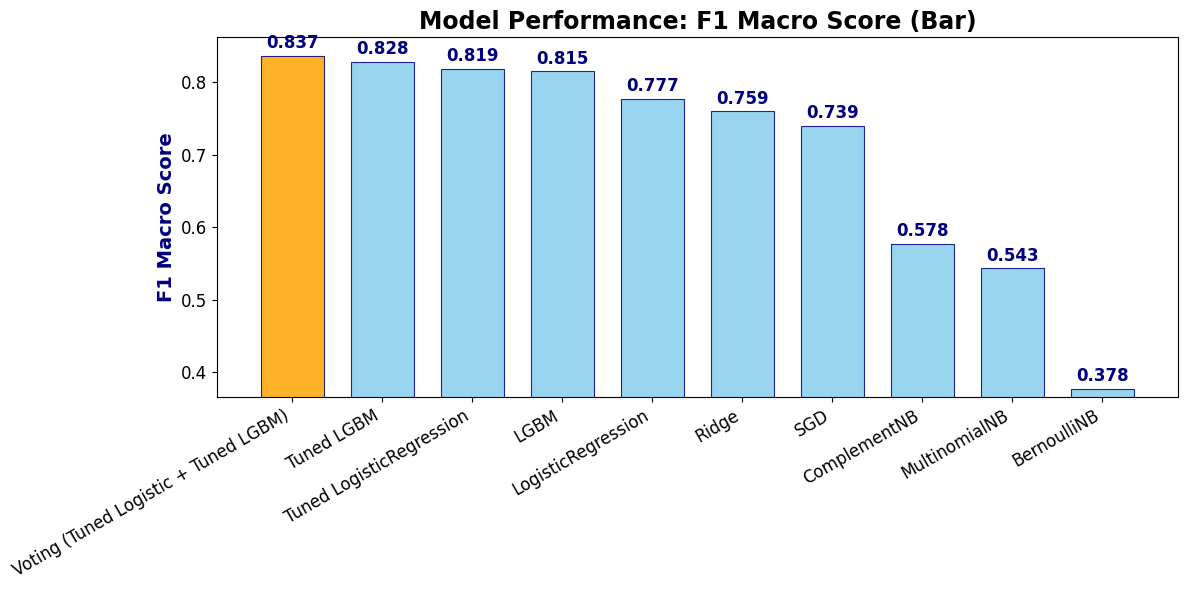

In [41]:
# Assuming df is your DataFrame with 'model_name' and 'f1_score' columns
df = final_results_df.sort_values(by="Holdout F1 Macro", ascending=False).reset_index(drop=True)

models = df['Model']
f1_scores = df['Holdout F1 Macro']
x = np.arange(len(models))

# Detect highest F1 score index
max_idx = f1_scores.idxmax()
colors = ['orange' if i == max_idx else 'skyblue' for i in df.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    x, f1_scores,
    color=colors,
    width=0.7,
    alpha=0.85,
    edgecolor='navy',     # Border color
    linewidth=.8           # Border thickness
)

# Y-axis label
ax.set_ylabel('F1 Macro Score', fontsize=14, fontweight='bold', color='navy')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(min(f1_scores)*0.97, max(f1_scores)*1.03)

# Annotate each bar
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
            f'{yval:.3f}',
            ha='center', va='bottom',
            fontsize=12, color='navy', fontweight='bold')

plt.title('Model Performance: F1 Macro Score (Bar)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()


# Final Best Model Report

In [42]:
best_final_model_name = final_results_df.iloc[0]["Model"]
best_final_model = fitted_models[best_final_model_name]

best_val_preds = best_final_model.predict(X_val)

print("Final selected model:", best_final_model_name)
print(classification_report(y_val, best_val_preds, target_names=[str(c) for c in label_encoder.classes_]))

Final selected model: Voting (Tuned Logistic + Tuned LGBM)
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.76      0.83      0.79      3183
           2       0.88      0.91      0.89     12488
           3       0.69      0.71      0.70      1094

    accuracy                           0.92     39600
   macro avg       0.83      0.85      0.84     39600
weighted avg       0.92      0.92      0.92     39600



# Final Confusion Matrix

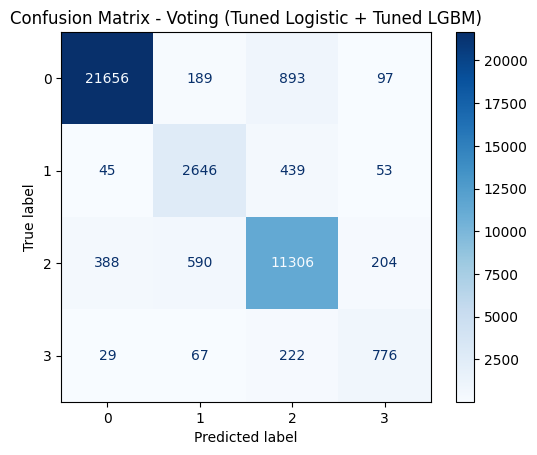

In [43]:
cm = confusion_matrix(y_val, best_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_final_model_name}")
plt.show()

The final confusion matrix shows that the ensemble reduces some of the earlier confusion for the difficult classes, although class 3 is still the hardest category. This indicates that the model has improved class balance, but there is still room for improvement in minority-class discrimination.

# Error Analysis of Misclassified Comments

Error analysis is important because it helps identify where the model is making mistakes and why.

By analyzing misclassifications, we can improve feature engineering, preprocessing, and model selection, leading to better performance and generalization.

In [44]:
error_analysis_df = X_val.copy()
error_analysis_df = error_analysis_df.reset_index(drop=True)

y_val_series = pd.Series(y_val).reset_index(drop=True)
pred_series = pd.Series(best_val_preds).reset_index(drop=True)

error_analysis_df["true_label"] = label_encoder.inverse_transform(y_val_series)
error_analysis_df["pred_label"] = label_encoder.inverse_transform(pred_series)
error_analysis_df["is_wrong"] = error_analysis_df["true_label"] != error_analysis_df["pred_label"]

errors = error_analysis_df[error_analysis_df["is_wrong"]].copy()

print("Number of wrong predictions:", errors.shape[0])
display(errors[["comment", "true_label", "pred_label"]].head(20))

Number of wrong predictions: 3216


,comment,true_label,pred_label
0,"And what are you expecting from the Pig? Do you really believe health insurance policies will go down when Obamacare is gone? It is going to be sad, so very sad when the Pig and its cronies do the...",2,0
5,The Liberal types hate free speech and especially anything that goes against their narrative,0,2
20,"A Palestinian State would be no more successful than the Palestinian Authority which is an untenable and strife-riven entity, with a dysfunctional polity and a collapsing economy -- with a miniscu...",1,2
44,"and yet another pathological lie; ""they're only working agriculture jobs Americans will not work,"" is debunked yet again.. Tell me, was it fair I had to compete with these illegal aliens for a job...",0,2
49,"Probably she does Possibly she does not. The only guarantee in this current presidential election is that the American people are going to be the big loser, whatever happens.",0,2
55,Lovely to see that Trudeau is at risk of losing support even from the weed advocates. We do need to ge trid of him.,3,2
65,"""Reasonable and stable""? Sorry dude, but lonr reasonable and stable people don't shoot their neighbor's pet to death on their neighbor's front lawn. QuickDraw McGraw's got issues.",2,3
68,Nonsense. One of the points you are in denial about is cultural genocide and the attempt to demonize the South. The North certainly had its villains from the psychopathic murdering terrorist John ...,2,1
74,"I question your mental state, media sx constantly referring to first black President, he;s not he is bi racial, according to your twisted mind that makes me a racist or something. National post re...",2,1
79,I hope the silly correspondence dinner dies raff too.,3,2


# Train Final Model on Full Training Data

After validation, the best model is retrained on the complete training data before generating predictions for the test set.

In [45]:
best_final_model.fit(X, y)

VotingClassifier(estimators=[('logistic',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('text',
                                                                                Pipeline(steps=[('selector',
                                                                                                 FunctionTransformer(func=<function <lambda> at 0x7f4ab805bce0>)),
                                                                                                ('tfidf_union',
                                                                                                 FeatureUnion(transformer_list=[('word_tfidf',
                                                                                                                                 TfidfVectorizer(max_df=0.9,
                                                                                                                                                 max_features=50000,
                                                                                                                                                 min_df=3,
                                                                                                                                                 ngram_range=(1,
                                                                                                                                                              2),
                                                                                                                                                 strip_accents=...
                                                                                 'is_weekend',
                                                                                 'race_flag',
                                                                                 'religion_flag',
                                                                                 'gender_flag',
                                                                                 'has_any_emoticon',
                                                                                 'txt_has_number',
                                                                                 'txt_has_url',
                                                                                 'txt_has_email',
                                                                                 'is_question',
                                                                                 'is_exclamation',
                                                                                 'is_short_comment',
                                                                                 'is_long_comment'])])),
                                              ('model',
                                               LGBMClassifier(class_weight={0: 1,
                                                                            1: 1.8,
                                                                            2: 1.0,
                                                                            3: 3.2},
                                                              n_jobs=-1,
                                                              objective='multiclass',
                                                              random_state=42,
                                                              verbose=0))]))],
                 n_jobs=-1, voting='soft', weights=[1.0, 2.1])

# Predict Test Data

In [46]:
test_preds_encoded = best_final_model.predict(X_test_final)
test_preds = label_encoder.inverse_transform(test_preds_encoded)


# Create Submission

In [47]:
submission = sample_submission.copy()
submission["label"] = test_preds

display(submission.head())

submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


submission.csv saved successfully


# Final Conclusion

This project presents a complete end-to-end solution for a multiclass comment category prediction problem by effectively combining textual, numerical, and contextual features within a structured machine learning pipeline.

The dataset is inherently complex because it is not purely text-based. It includes user-generated comments along with engagement signals, emoticon indicators, identity-related attributes, and hidden internal features. Therefore, a hybrid approach was necessary, where both text modeling and structured feature engineering were equally important.

During the exploratory data analysis phase, several important observations were made. The target variable was found to be imbalanced, which justified the use of Macro F1-score instead of accuracy as the primary evaluation metric. Textual analysis showed high variability in comment length and structure, supporting the inclusion of text-meta features such as length, punctuation intensity, lexical diversity, and uppercase ratio. Engagement features like upvotes and downvotes exhibited skewed distributions with significant outliers, motivating the use of log transformations and ratio-based features. Additionally, temporal patterns and identity-related indicators were found to contribute useful contextual signals.

Feature engineering played a crucial role in improving model performance. In addition to TF-IDF vectorization of text (using both word-level and character-level representations), several structured features were created, including:

engagement-based features (total reactions, net votes, controversy)
text structure features (length, punctuation, word statistics)
identity-related signals (presence flags and counts)
temporal features (weekday, hour, recency)
interaction features combining identity and engagement

For modeling, multiple algorithms were evaluated to capture different aspects of the data. Linear models such as Logistic Regression, Ridge, and SGD performed well due to the high-dimensional sparse TF-IDF features. However, LightGBM emerged as the best baseline model, demonstrating the importance of nonlinear interactions among structured features. Naive Bayes models performed significantly worse, indicating that the dataset is too complex for simple independence assumptions.

Hyperparameter tuning of Logistic Regression provided modest improvements, confirming that it was already a strong baseline. However, it did not surpass tuned LightGBM. To leverage complementary strengths, a soft voting ensemble of tuned Logistic Regression and tuned LightGBM was implemented.

The ensemble achieved the highest Macro F1-score on the validation set. Although the improvement over LightGBM was relatively small, it was meaningful because it improved performance on the harder classes, particularly those with lower recall in the baseline model. This is an important observation, as improvements in Macro F1 often come from better handling of difficult or minority classes rather than further optimizing already well-predicted classes.

Class-wise analysis using classification reports and confusion matrices revealed that:

classes 0 and 2 are easier to classify with high precision and recall
class 3 is the most challenging, often confused with class 2
class 1 shows moderate difficulty with some overlap

The ensemble model helped reduce some of these confusions, leading to more balanced performance across classes.

Error analysis further showed that misclassifications often occur in cases involving:

ambiguous wording
overlapping semantic patterns
subtle contextual differences
indirect or nuanced expressions

This indicates that the model is already capturing strong patterns, and remaining errors are largely due to inherent ambiguity in the data rather than clear modeling failures.

Overall, the final model demonstrates strong performance, achieving a good balance between accuracy and Macro F1-score while maintaining robustness across all classes. The pipeline is:

well-structured and reproducible
leakage-aware and methodologically sound
supported by thorough EDA and feature engineering
validated through multiple models and class-wise evaluation

In conclusion, this project successfully combines domain understanding, feature engineering, and model selection to build a reliable and interpretable solution for comment classification. While the current model performs well, further improvements could potentially come from:

more advanced text representations within allowed constraints
better handling of ambiguous cases
refined feature interactions

However, within the given constraints and dataset, the current solution provides a strong and well-justified approach.